# Lab 053 · RealMLP & strong defaults

[Lesson](../lessons/0053-realmlp-strong-defaults.html) · [Reference](../reference/realmlp-strong-defaults.html)

**Skill:** implement numeric RealMLP-TD-S and audit a fixed recipe versus tuned XGBoost. **Scope:** complete numeric TD-S forward path and training recipe, binary classification and regression; not full TD, categories or the paper benchmark. Four TODO functions feed the live training code. PROVIDED = read/run; CHECK = immediate diagnostic feedback; EXIT = explain your result.

**Reproducibility contract:** Tier A real California Housing, House 16H and Higgs Small data from the TabR release, not RealMLP benchmark splits. Preserve released boundaries; label-blind row caps 1200/600/600, selection seeds 53/54/55; model seeds 0/1/2. Train-only numeric statistics and target standardization. Learning recipe: width 64, three hidden layers, 64 epochs, batch 256, all four schedule cycles; six XGB candidates, 150 trees each, patience 20. **INCOMPARABLE** to the paper benchmark. See [contract](l053-reproduction.md).

The historical comparison took about 30 CPU seconds after setup; the added clipping intervention runs nine more neural fits and may take another minute. Downloading dependencies/data takes longer. Implementation and interpretation deserve a separate session. Static figures are labeled author-reference snapshots; your live results appear only when you run the experiment.

**Recall first:** Explain why three random model seeds do not give three independent datasets. Then predict whether selecting a lower validation error guarantees a lower test error.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — runtime and data setup
import os,sys,math,copy,hashlib,json,time,importlib.metadata
from pathlib import Path
os.environ['OMP_NUM_THREADS']='1';os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ.setdefault('MPLCONFIGDIR','/tmp/relational-matplotlib')
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import rankdata,friedmanchisquare,studentized_range
from threadpoolctl import threadpool_limits
from xgboost import XGBClassifier,XGBRegressor
torch.set_num_threads(1)
for candidate in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (candidate/'relkit').is_dir():
        LABS=candidate.resolve();os.chdir(LABS);sys.path.insert(0,str(LABS));break
else:raise RuntimeError('Use the Colab bootstrap or run inside this repository')
from _fetch_l052 import fetch
from relkit.tabr_experiment import seed_interval
fetch()
print({p:importlib.metadata.version(p) for p in ['torch','numpy','scipy','scikit-learn','xgboost']})
print('Data manifest SHA256',hashlib.sha256((LABS/'_data_l052.json').read_bytes()).hexdigest())

## A strong network is a training recipe, not just a diagram

<a href="../lessons/0052-tabr-retrieval.html">TabR</a> added an explicit memory. RealMLP asks how far a carefully designed parametric baseline can go without that route. Its claim about defaults links three levels: stable input scales, a favorable optimization path, and transfer of the recipe to new datasets. Read the preprocessing and schedule as causes of the fitted predictor, rather than as disconnected implementation tips.

## 1. Default is a transfer claim




A **parameter** is learned while fitting a model, such as a matrix entry. A **hyperparameter** controls fitting, such as hidden width, learning rate or dropout probability. A **default configuration** specifies these choices before seeing a new task’s results. Calling it default says little about the effort spent developing it.




The paper develops configurations across a collection of **meta-train datasets** and evaluates their transfer to separate **meta-test datasets**. “Meta” identifies the level: the objects being separated are entire prediction problems, not merely rows. Within each problem, training rows fit weights, validation rows guide permitted selection, and test rows score the resulting procedure. These two boundaries solve different problems. [Source: §2.](https://arxiv.org/html/2407.04491v3#S2)





Suppose you try five learning rates on datasets A–D, freeze one, and train on E. That is default use on E. If you inspect E’s test error, change the rate, and report the new error as untouched evaluation, E has entered development. The same issue appears when researchers repeatedly change architectures against a familiar benchmark. A train/test row split does not erase that history.




A frozen procedure can still use validation to choose an epoch. “No per-task hyperparameter search” does not mean “no validation.” The paper’s recipe explicitly includes checkpoint selection. The relevant claim is that the entire procedure was fixed before evaluation on new tasks.





### What the paper actually supports



[Section 5.2 and Figure 2](https://arxiv.org/html/2407.04491v3#S5.S2) report that RealMLP's gap between tuned defaults and per-task optimization stays similar on meta-train and meta-test. This supports transfer of its recipe. The paper's HPO baseline uses 50 random-search trials per dataset split; our six-candidate tree search is much smaller.





| Published finding | Boundary on the conclusion |
| --- | --- |
| RealMLP/RealTabR are competitive with boosted trees on aggregate benchmark scores. | On the Grinsztajn classification benchmark, RealMLP is worse than CatBoost. The winner depends on the benchmark and metric. |
| Selecting among several tuned-default model families is often competitive with single-family HPO at lower runtime. | This supports a portfolio procedure, not the claim that one MLP always wins. |
| Both architectural and training changes contribute. | Cumulative ablations depend on addition order and retune the learning rate. They do not identify a context-free contribution for each component. |





The paper also reports an XGBoost rare-category encoding bug, discusses metric dependence, and leaves transfer to distribution shift uncertain. Our numeric-only test does not exercise that categorical bug. Read these results as evidence for testing strong neural and tree recipes, not a universal architecture ranking.




The paper uses ten random 60/20/20 splits per dataset and aggregates errors across tasks, with dataset-group weighting on meta-train. Its shifted geometric mean adds a small positive offset before taking logs, reducing sensitivity to zero classification error. That aggregate is not a raw California RMSE, and neither is interchangeable with our rank summary. Do not compare a local number to a paper figure merely because both axes say “error.” [Source: §2.2.](https://arxiv.org/html/2407.04491v3#S2.S2)

### A default is a learned decision made before this dataset

A hyperparameter chosen using the current validation set is a local adaptation. A default chosen on other development datasets is transferred knowledge about which training procedure often works. Both can be useful, but they spend information in different places. “No tuning” on a new dataset does not mean no human or computational effort went into designing the recipe.

RealMLP is valuable here because it treats the training recipe as a central object. Input scaling, parameterization, activation, optimizer groups and learning-rate schedule jointly determine how an otherwise familiar MLP learns. Comparing its network diagram alone with an older MLP misses much of the proposal.

Separate the full method from the specific TD-S variant implemented in the lab. A reduced-width local run also differs from a published-width recipe. Use these names in result tables so an exploratory run cannot silently inherit the scope of the paper's strongest result.

The appropriate baseline question depends on deployment. If you can afford extensive search, compare tuned procedures under a declared budget. If you need a reliable first run on many tables, compare defaults and measure their failure rate as well as average score. A procedure that is excellent after rescue tuning may be a poor default for an automated system.

Defaults can overfit their development suite too. A recipe that repeatedly receives feedback from the same collection of datasets may exploit their shared properties. The strongest transfer evidence comes from tasks that did not guide those design decisions. This is the dataset-level analogue of keeping test labels out of model selection.

### Reconstruct the paper's unit of evidence

The paper's Table 1 contains **118 meta-train datasets** (71 classification, 47 regression) and **90 meta-test datasets** (48 classification, 42 regression). The additional Grinsztajn benchmark contains 18 classification and 28 regression tasks under this paper's filtering. Those are several different populations, not one pooled leaderboard. Meta-train contains related dataset variants, so their weights compensate for group size; meta-test datasets receive equal weight. [Paper §2, Table 1 and Appendix C.3](https://arxiv.org/html/2407.04491v3#S2).

Within each dataset the paper draws ten random 60/20/20 train/validation/test splits. For a candidate default, training rows fit weights and validation chooses the checkpoint. Split test errors on **meta-train datasets can then inform recipe development**: these datasets are development material at the outer level. Only the separate meta-test datasets provide the held-out transfer evaluation. Requiring every meta-train row test to remain untouched by recipe development would describe a different, more restrictive experiment. The crucial boundary is to stop that feedback before meta-test.

The benchmark score is not an average raw RMSE and not the three-task mean rank used below. Let eᵢⱼ denote the error for dataset i and split j. Classification uses a fraction of wrong labels. Regression uses normalized RMSE: RMSE divided by the standard deviation of the evaluated targets, making it dimensionless. This metric normalization is distinct from the training target standardization used by the network. The benchmark separately aggregates classification and regression.

With normalized dataset weights wᵢ summing to one, its **shifted geometric mean** is

**S = exp(Σᵢ wᵢ (1/10) Σⱼ log(eᵢⱼ + 0.01)).**

Read the operations in order: add 0.01 to protect zero errors; take logarithms; average over splits and weighted datasets; exponentiate. There is **no subtraction of 0.01 afterward** in this paper's definition. The score is lower-is-better, but it is not an accuracy or a single dataset's error. [Paper §2.2](https://arxiv.org/html/2407.04491v3#S2.SS2).

**Worked example, synthetic, one split for clarity.** On two equally weighted tasks, method A has errors [0.01, 0.41] and B has [0.04, 0.36]. Arithmetic mean errors are 0.21 and 0.20, favoring B. The paper's calculation gives S(A)=√(0.02×0.42)≈0.09165 and S(B)=√(0.05×0.37)≈0.13601, favoring A. A's low-error improvement matters more on a relative scale. This is not a contradiction: the aggregation encodes what counts as an improvement. Adding a third model can change mean ranks; it cannot change these two independently defined scores.

The paper's confidence intervals treat its **datasets as fixed and splits as random**. Appendix C.6 averages log-errors across datasets at each split index, computes a t interval across those split-index summaries, then exponentiates the endpoints. They do not estimate uncertainty over all possible future datasets. Our three model-seed intervals condition on both datasets **and the one chosen split**, so they cover a narrower source of variation. Neither interval turns a convenient benchmark into a random sample of every deployment problem.

### Read the headline as a procedure comparison

The paper compares library defaults (D), defaults developed on other tasks (TD), and 50-trial per-split random search (HPO). Its Best-TD procedure validates a small portfolio: RealMLP, XGBoost, LightGBM and CatBoost. Selecting among four fixed methods is still per-task algorithm selection, even though each candidate avoids per-task hyperparameter search. Ensemble-TD combines that portfolio through validation-based greedy selection; it has a different inference cost from retaining one winner. Our six-candidate XGBoost experiment recreates neither procedure. [Paper §5.1 and C.2](https://arxiv.org/html/2407.04491v3#S5.SS1).

Figure 2 supports competitive benchmark performance and a time/error tradeoff under those choices. It does not isolate architecture: preprocessing, optimizers and selection rules differ across methods. On the Grinsztajn classification benchmark, RealMLP performs worse than CatBoost, while changing classification error to AUROC favors trees more. The figure also flags an XGBoost rare-category handling bug in some results. Timings depend on hardware and parallelization and are normalized using measurements on meta-train tasks. Carry those conditions with the claim instead of saying that a plain MLP universally beats tuned trees. [Paper §5.2, Figures 2–3 and C.7](https://arxiv.org/html/2407.04491v3#S5.SS2).

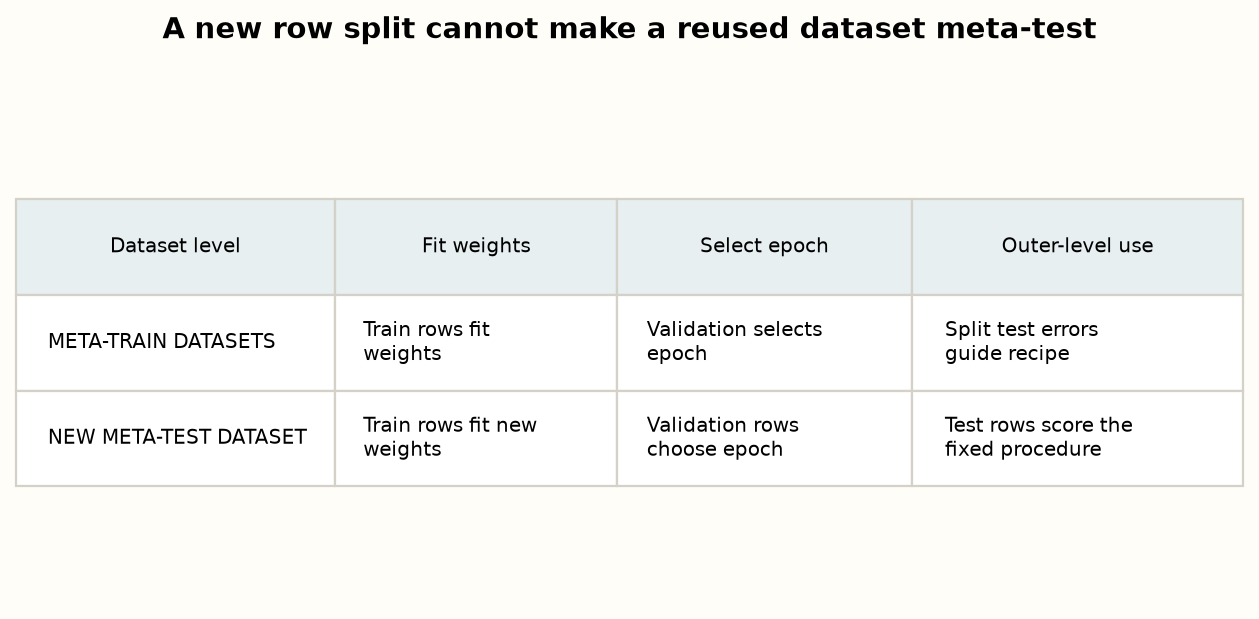

Two evaluation levels: meta-train split test errors can guide recipe development; on separate meta-test datasets, freeze the recipe, fit fresh weights and select epochs. [Open full-size figure](figures/l053/boundaries.png). On a small screen, open the full-size figure to inspect labels and seed points.

In [ ]:
# CHECK — reconstruct the paper score on the synthetic example, not lab errors
example_a=np.array([.01,.41]);example_b=np.array([.04,.36])
score_a=np.exp(np.log(example_a+.01).mean())
score_b=np.exp(np.log(example_b+.01).mean())
assert example_a.mean()>example_b.mean() and score_a<score_b
np.testing.assert_allclose([score_a,score_b],[np.sqrt(.02*.42),np.sqrt(.05*.37)])
print('Synthetic arithmetic means:',example_a.mean(),example_b.mean())
print('Synthetic paper scores (no shift subtraction):',score_a,score_b)

### Retrieval check
You change a default after examining dataset E's test results, then make a fresh row split on E. Is E now a new meta-test dataset? Write an answer before opening the feedback.

<details><summary>Compare your reasoning</summary>No. You refreshed a row split, but E already influenced the recipe. Meta-test status concerns dataset-level development history.</details>

### RealMLP-TD-S: the predictor and how it is learned

**Trace before reading:** Why does matching hidden-layer widths fail to reproduce this procedure?

<div style="max-width:100%;overflow-x:auto">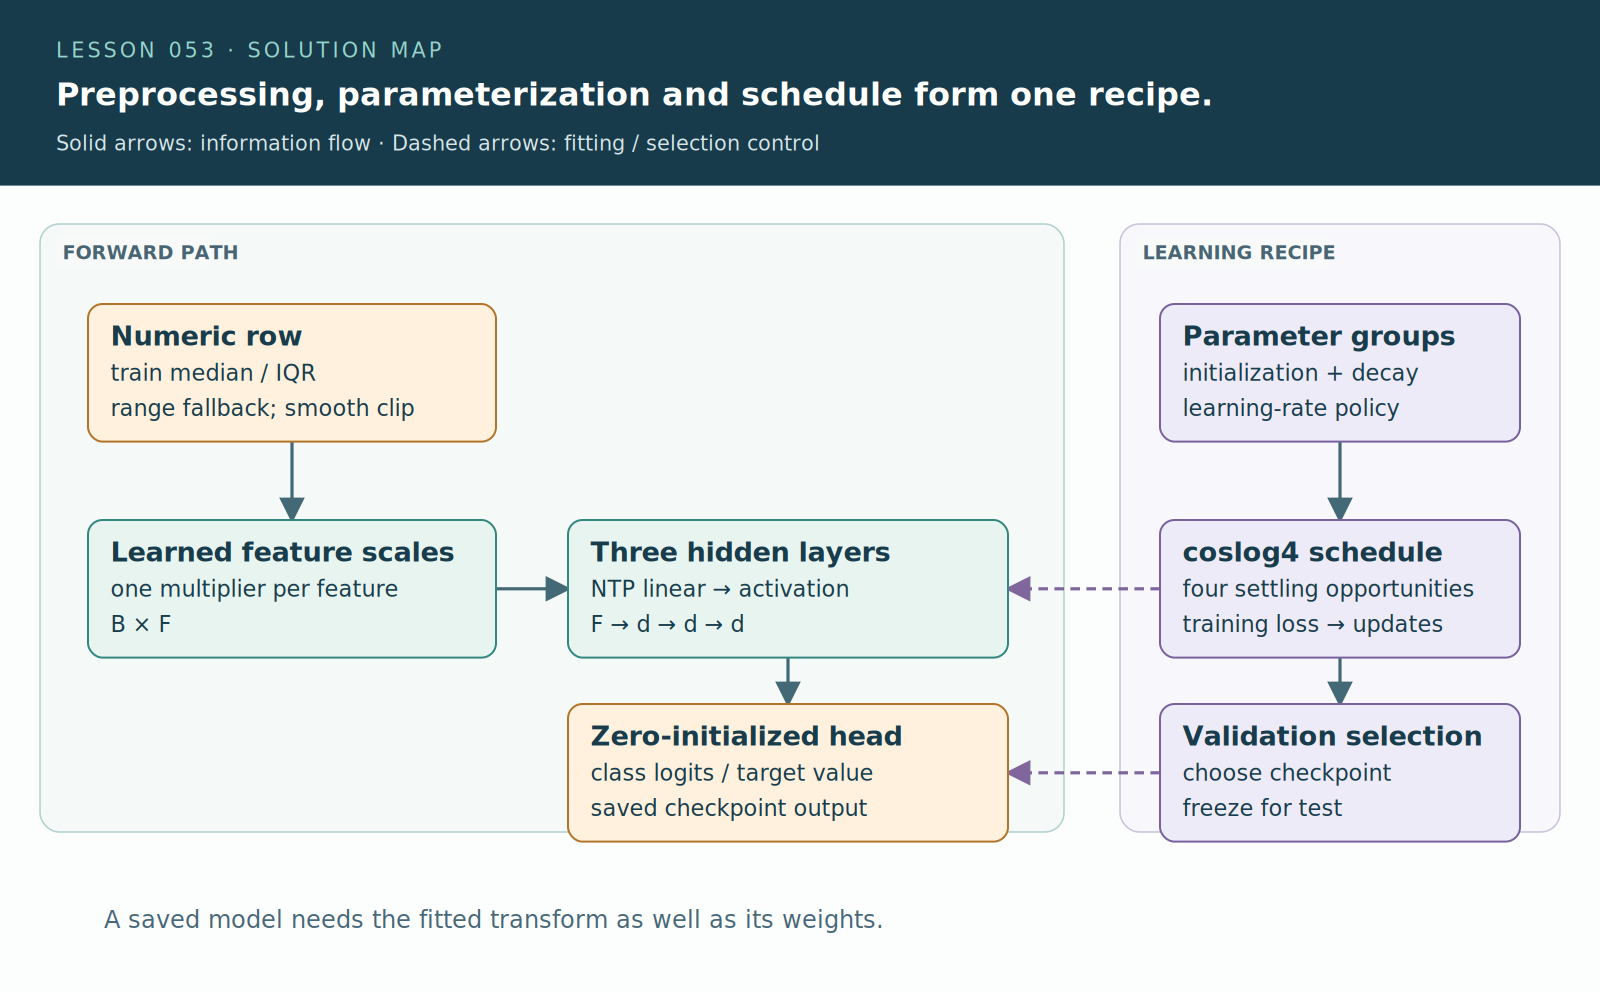</div>

**How the parts work together:** The transform fixes input scale, trainable feature scales adapt it, NTP parameterization controls layer scale, and the optimizer schedule controls the path to a validation-selected checkpoint. Width describes only part of that system.

**Pictured scope:** Numeric TD-S: local width64; paper recipe width256. Three hidden layers; SELU for classification, Mish for regression. Categorical/full-TD paths are outside this diagram.

[Full-size vector diagram](../assets/solution-maps/0053-recipe-system.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Numeric row</strong>: train median / IQR; range fallback; smooth clip. Connects to Learned feature scales.</li><li><strong>Learned feature scales</strong>: one multiplier per feature; B × F. Connects to Three hidden layers.</li><li><strong>Three hidden layers</strong>: NTP linear → activation; F → d → d → d. Connects to Zero-initialized head.</li><li><strong>Zero-initialized head</strong>: class logits / target value; saved checkpoint output.</li><li><strong>Parameter groups</strong>: initialization + decay; learning-rate policy. Connects to coslog4 schedule.</li><li><strong>coslog4 schedule</strong>: four settling opportunities; training loss → updates. Connects to Three hidden layers (fitting/selection control); Validation selection.</li><li><strong>Validation selection</strong>: choose checkpoint; freeze for test. Connects to Zero-initialized head (fitting/selection control).</li></ol></details>

## 2. Model architecture




Our scope is the **complete numeric forward path of RealMLP-TD-S**, with its training recipe. The full TD variant additionally has feature embeddings, parametric activations, data-dependent initialization, scheduled dropout and weight decay. Those are not secretly present in this lab, and its results must not be labeled full RealMLP-TD. For categorical inputs TD-S uses one-hot encoding, but our implementation deliberately accepts numeric arrays only. [Source: Appendix A.2 and Table A.1.](https://arxiv.org/html/2407.04491v3#A1.SS2)




The model processes one row at a time. Preprocessing yields a vector u of length p. Learned feature scales produce h₀=u⊙s, where ⊙ means coordinate-wise multiplication. Three hidden stages transform the vector with a linear map and a nonlinear activation. A final linear head predicts either two class scores or one standardized regression target. B simply groups independent rows for efficient computation.




For classification, **logits** are unnormalized class scores. Softmax turns scores a into probabilities using exp(aᵢ)/Σⱼexp(aⱼ). Even binary classification has two output neurons here. For regression, predictions are converted back to the target’s original units using the training target mean and standard deviation. TD-S does not clip predictions to the observed target range.




There is no pretraining stage or retrieval memory. The target is supplied to a loss during supervised training; it is not an input to the forward pass. Once fitted, inference needs the row, preprocessing statistics and learned weights.

### What the simplified variant deliberately leaves out

TD-S is an author-defined variant, not our ad hoc substitute. Its principal benefit for this lesson is that the whole numeric computation and trainer fit in visible code. Width 64 and 64 epochs are our additional reductions. Full TD's classification rate is also 0.04, but its regression base rate is **0.2**, versus **0.07 for TD-S**; adding TD components while retaining every TD-S setting would not recreate TD. [Table A.1 and Appendix A.2](https://arxiv.org/html/2407.04491v3#A1.SS2).

| Stage | Full TD | TD-S, before our numeric-only restriction |
|---|---|---|
| Categories | One-hot through cardinality 8; learned 8-dimensional embeddings for larger categories | One-hot for every categorical feature; binary categories use one ±1 coordinate, unknown/missing encode as zero in the pinned standalone |
| Numerical representation | Four-dimensional PBLD representation for each original numeric feature | The robust-scaled, smoothly clipped scalar itself |
| Activation | Learned interpolation between identity and SELU/Mish | Fixed SELU/Mish |
| Initialization | Training-data-dependent hidden and head initialization | Standard-normal hidden weights/biases; zero head |
| Regularization | Dropout and weight decay, both scheduled | Neither |
| Regression output | Clip to observed training target range | No output clipping |

Here is the numerical embedding rather than just its name. For one processed scalar u, full TD computes 16 periodic responses **r=cos(2πwu+b)**, then projects them to three values **v=Ar+c** and concatenates the original scalar: **[u,v₁,v₂,v₃]**. Here w,b have length 16, A has shape [3,16], and c has length 3. The direct u route retains an ordered scalar even though the cosine route can encode several values similarly. For a synthetic single-frequency example, cos(2πu) gives the same value at u=0 and u=1; retaining u distinguishes those inputs. PBLD stands for periodic bias linear DenseNet; in this use, the “dense” connection is that scalar concatenation. The learned frequencies and projection can offer useful scalar representations before feature interaction, but do not establish robustness to arbitrary shifts. [Paper §3](https://arxiv.org/html/2407.04491v3#S3).

A full-TD activation computes **(1−α)x+ασ(x)** per neuron, starting at α=1. At α=0 it is the identity; at α=1 it is SELU or Mish. α is a learned parameter, not restricted to [0,1], so this is an algebraic interpolation rather than a probability mixture. Full TD also starts dropout at 0.15 and weight decay at 0.02. Their flat_cos multiplier is 1 during the first half of training, then follows a cosine to zero; this schedule differs from the four learning-rate cycles. A reader copying “all schedules are coslog4” would implement a different method. These paths are explained here as source context, **not implemented or measured by our numeric TD-S lab**.

### Connect recipes to the surrounding models

In L050, FT-Transformer turns columns into tokens and learns attention between columns. A RealMLP dense layer instead mixes the whole row through a fixed learned matrix, followed by nonlinearities. Both require a fitting recipe. Improving that recipe is a necessary control before crediting token attention for a win. Full TD's PBLD changes the scalar representation before mixing; it does not introduce attention.

L052 TabR consults labeled training examples at prediction time. Numeric TD-S stores its learned information in weights and preprocessing state; deleting training rows after fitting does not change a TD-S prediction. The paper's RealTabR-D combines the retrieval idea with several RealMLP recipe changes, demonstrating that these directions can be complementary. It does **not** copy all TD-S settings: Appendix A.3 uses a differently parameterized feature-scale factor of 96 and omits changes that worsened performance or cost too much. An improvement to a recipe should be transferred as an experiment, not as an unconditional rule. [Paper Appendix A.3](https://arxiv.org/html/2407.04491v3#A1.SS3).

For the relational mission, consider predicting whether a customer will renew. A strong default can improve learning from existing columns such as tenure and recent spend. It cannot observe an account's linked support history unless those records are exposed through features or a relational model. A convincing relational comparison first makes those input-information boundaries explicit, then compares fitting recipes and selection budgets. L054's efficient ensembles add another boundary: multiple members versus one model. More predictions can improve a procedure without proving that each member is a better architecture.

**Connecting the ideas.** The forward map starts before the first learned layer. Robust statistics and smooth clipping control the magnitudes that the optimizer will encounter. This is why a preprocessing detail can change training even when the hidden-layer graph is identical.

## 3. Make input scale predictable




A neural update depends on input magnitudes. A currency column, a binary indicator and a heavy-tailed count can otherwise arrive on very different scales. RealMLP first centers each column at its training median and rescales by its **interquartile range** (IQR), the 75th percentile minus the 25th percentile. Quantiles describe positions in a sorted sample. Extreme observations therefore have less influence on these fitted statistics than on the mean and standard deviation.




For one column, let m be its median, q its IQR and r its maximum minus minimum, all computed on training rows. Set a=1/q when q>0; if q=0 but r>0, use a=2/r; if the column is constant, use a=0. Then z=a(x−m). The fallback matters for sparse columns: most values can be identical while a few differ. A constant training column stays zero at inference even if a new value appears.




Next apply `u = z / √(1 + (z/3)²)`. This **smooth clipping** transformation approaches −3 and +3 in the tails. Unlike hard clipping, distinct finite inputs remain ordered in exact arithmetic. Its derivative is `(1+z²/9)−3/2`: positive everywhere, near one around zero and small in the tails. Saturation compresses differences; it does not prove that outliers are irrelevant. [Source: author preprocessing.](https://github.com/dholzmueller/realmlp-td-s_standalone/blob/a8c73f75dbeae4ab1ba5bc92372c444ffa0f766e/preprocessing.py)





**Trace:** with median 0, IQR 2 and raw x=4, z=2 and u≈1.664. Predict what happens as z grows before moving the slider. Its fitted statistics stay fixed.




The notebook’s first two tasks implement the fitted statistics and the smooth transform. Fitting preprocessing on validation or test rows would change the information contract. Our loader fits an extra median imputer on training rows if needed; that is an explicit local safeguard, whereas the paper benchmark removes rows with missing numeric values.

### Derive the transform one stage at a time

The local numeric preprocessing first centers a feature by its training median and scales it using a training interquartile range. The median is a location estimate; the interquartile range measures the middle half of the data. These estimates are less directly controlled by a single extreme value than the mean and full range.

If the interquartile range is zero but the feature is not constant, the implementation uses a fallback based on half the training range. If the feature is constant, it assigns a zero scaling factor. These branches prevent division by zero and define what an uninformative training coordinate contributes. They are part of the algorithm, not incidental numerical cleanup.

After scaling, the smooth clipping function is c(z)=z/√(1+(z/3)²). At z=0 it returns 0. At z=3 it returns 3/√2≈2.121. At z=6 it returns 6/√5≈2.683. As z grows positive, the output approaches 3; for large negative z it approaches −3.

Unlike hard clipping, this mathematical function remains strictly increasing for every finite real z. In floating-point code, nearby tail values can round to the same number; sufficiently extreme inputs can overflow the squared term. The claim about ordering is an exact-arithmetic property, not a numerical guarantee. Its derivative is (1+z²/9)^(−3/2), which is positive and becomes small in the tails. Large values are compressed rather than all mapped to exactly the same boundary. In exact arithmetic this preserves ordering while limiting magnitude.

The transform does not make all features Gaussian, and it does not remove every outlier problem. It controls one aspect of input scale. A rare but informative extreme can become harder to distinguish after compression; whether this trade-off helps is empirical.

Trace a future value using stored training statistics. Recomputing the median or scale for each query batch would make the prediction depend on unrelated co-batched rows. The preprocessing state should be fitted once under the declared training boundary and serialized with the model.

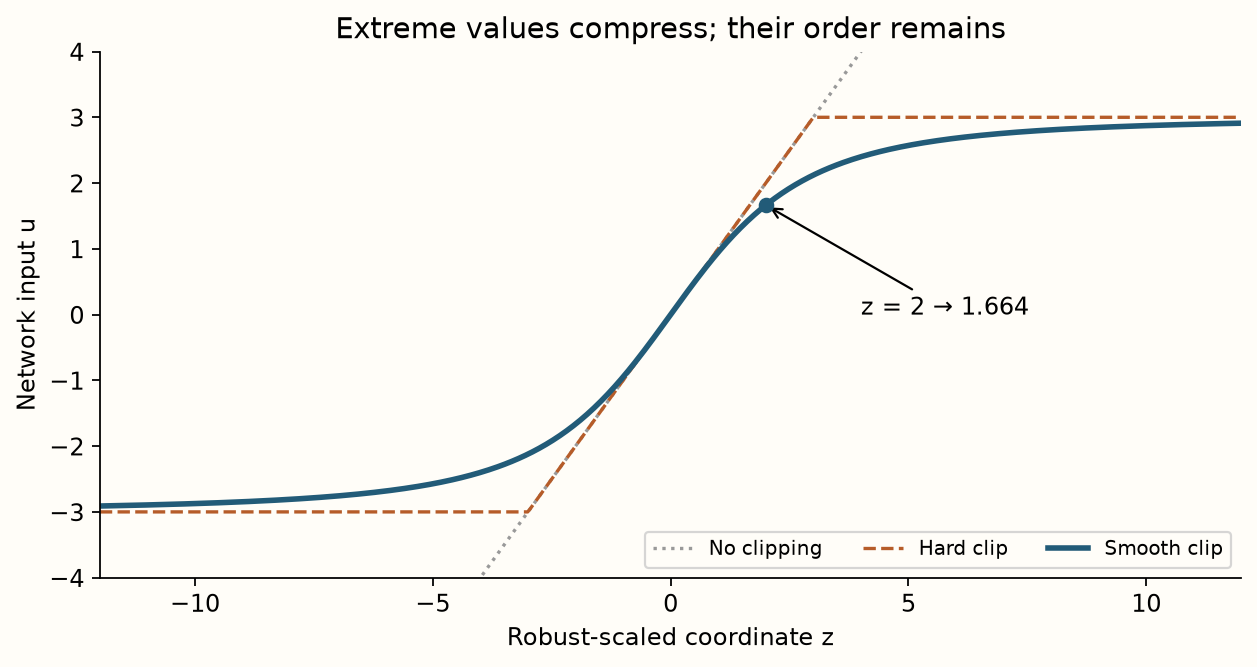

Synthetic smooth clipping trace: z=2 maps to 1.664, while the function approaches ±3 in the tails. [Open full-size figure](figures/l053/preprocessing.png). On a small screen, open the full-size figure to inspect labels and seed points.

### TODO 1 · Fit robust statistics
**Goal:** return two vectors, training-column medians and multiplicative scales. **Why:** new-task preprocessing must be defined even for sparse or constant columns. Input is a finite 2D NumPy array. Implement all three cases described above without dividing by zero. Do not use validation rows.

In [ ]:
# TODO — robust_parameters
def robust_parameters(x):
    raise NotImplementedError("Implement this live function")

In [ ]:
# CHECK — zero-IQR nonconstant, ordinary IQR, constant, and scale equivariance
x=np.array([[0.,1.,7.],[0.,2.,7.],[0.,3.,7.],[0.,4.,7.],[10.,5.,7.]])
m,s=robust_parameters(x)
np.testing.assert_allclose(m,[0,3,7]);np.testing.assert_allclose(s,[.2,.5,0])
m2,s2=robust_parameters(10*x+17)
np.testing.assert_allclose(m2,10*m+17);np.testing.assert_allclose(s2,s/10)
assert np.isfinite(s).all()
print('PASS: IQR fallback, constants and affine unit changes')

### TODO 2 · Compress the tails
**Goal:** implement the smooth transform elementwise for a NumPy array. **Why:** bound extreme inputs while retaining finite-value ordering. The recap defines the function; your code must handle positive, negative and zero inputs without changing array shape.

In [ ]:
# TODO — smooth_clip
def smooth_clip(z):
    raise NotImplementedError("Implement this live function")

In [ ]:
# CHECK — independent values, odd symmetry, order and strict finite bounds
z=np.array([-30.,-3.,0.,3.,30.]);v=smooth_clip(z)
np.testing.assert_allclose(v[1:4],[-3/np.sqrt(2),0,3/np.sqrt(2)])
np.testing.assert_allclose(v,-smooth_clip(-z));assert (np.diff(v)>0).all()
assert (np.abs(v)<3).all() and v.shape==z.shape
print('PASS: monotonic compression, not hard clipping')

In [ ]:
# PROVIDED — train-fitted transform wrapper
class RobustSmooth:
    def fit(self, x):
        x = np.asarray(x, dtype=np.float64)
        if x.ndim != 2 or not len(x) or not np.isfinite(x).all():
            raise ValueError('Fit requires a nonempty finite numeric matrix')
        self.median, self.scale = robust_parameters(x)
        return self

    def transform(self, x):
        return smooth_clip((np.asarray(x) - self.median) * self.scale).astype('float32')

**Connecting the ideas.** Input scale is only one side of the optimization problem. Parameterization and initialization determine how changes in weights alter the function. A network can express the same functions yet reach different ones under a fixed training budget.

## 4. Same function family, different optimization




A learned feature scale sⱼ multiplies coordinate uⱼ before the first dense layer. All scales start at one. This can downweight an input, but it is *soft* feature selection: scales are not binary masks, may become negative, and can trade off against downstream weights. A small scale alone is not a reliable causal-importance score.




The dense layers use **neural tangent parameterization** (NTP): `a = hW/√dᵢₙ + b`. Here h is [B,dᵢₙ], W is [dᵢₙ,dₒᵤₜ], and b is [1,dₒᵤₜ]. The factor divides the matrix product, not the bias. If independent centered inputs and weights each have variance one, a sum of dᵢₙ products has variance dᵢₙ; dividing by √dᵢₙ keeps its variance near one. That is an initialization argument with assumptions, not a guarantee about trained activations.




One can absorb 1/√dᵢₙ into a conventional linear weight, so this does not by itself create new functions. It changes how stored parameter updates translate into function changes. An update ΔW produces `Δa=hΔW/√dᵢₙ`. Copying the same learning rate between parameterizations therefore does not copy the effective learning dynamics. Adam’s normalization adds another reason to avoid claiming identical optimization from algebraic forward equivalence.




Use the diagram’s fixed weight column [1,−1,2,1] and bias 0.5. Changing only the first scale from 1 to 2 makes the input [2,2,−1,0], its dot product −2, and the preactivation −2/2+0.5=−0.5. The original preactivation was −1. Predict the sign change threshold before using the control.




Hidden weights and biases start as standard normal draws: a distribution with mean zero and variance one. The output weights and bias start at zero. Initial regression predictions therefore equal the training target mean after unscaling; initial two-class probabilities are (0.5,0.5). The zero output matrix initially blocks loss gradients into hidden layers, while the head can receive gradients. This does not keep the network frozen: after the head changes, gradients can propagate upstream. [Source: NTPLinear and SimpleMLP.](https://github.com/dholzmueller/realmlp-td-s_standalone/blob/a8c73f75dbeae4ab1ba5bc92372c444ffa0f766e/mlp.py)




Classification uses SELU: approximately 1.0507x for positive x and 1.0507×1.6733×(exp(x)−1) otherwise. Regression uses Mish: `x tanh(log(1+exp(x)))`, computed with a numerically stable softplus. Both preserve a nonlinear response to negative inputs; neither is a learned activation in TD-S. These are prescribed recipe choices, not mechanisms we separately prove superior in this experiment.

### Reparameterization changes the optimizer's coordinates

Consider a linear layer written as y=xW/√d+b, where d is the input width. A conventional layer could represent exactly the same function by storing W′=W/√d. Equal representational capacity does not imply equal gradient-descent trajectories, because the optimizer updates the stored parameters rather than abstract functions.

In one coordinate, let the effective coefficient be a=w/√d and the loss derivative with respect to a be g. Then ∂L/∂w=g/√d. A gradient step w←w−ηg/√d changes the effective coefficient by Δa=−ηg/d. Directly updating a with the same nominal learning rate would instead give Δa=−ηg. Parameterization and learning rate must therefore be interpreted together.

This illustration isolates plain gradient descent; adaptive optimizers add their own state and scaling. It still explains why “same width and learning rate” is not enough to identify the same training procedure. Read the actual layer definition and optimizer parameter groups.

The local TD-S recipe gives different learning-rate factors to input-scale parameters, ordinary weights and biases. The input scale can change how strongly each feature reaches the hidden network. Bias updates move activation thresholds. Their roles and desired update magnitudes need not match those of a large weight matrix.

The zero-initialized output layer provides another instructive gradient trace. On the first backward pass, hidden-layer gradients transmitted through an exactly zero output weight are zero, while the output layer can receive a nonzero gradient from the hidden activations. The first scheduled rate is zero, so that backward pass updates Adam moments but not the head. At the next positive-rate update the head can move; a subsequent backward pass can then reach earlier layers. This is an optimization behavior you would miss in a box labeled only “MLP head.”

When implementing the model, inspect parameter names, group membership and initial values. A network can have the correct forward shapes and still train differently because every parameter accidentally received the same optimizer settings.

### TODO 3 · Width-scaled linear computation
**Goal:** return the NTP preactivation with W stored as [input,output]. **Why:** placing the scaling factor on the bias changes the function. Use torch operations so gradients reach inputs, weights and biases; support arbitrary batch size and widths.

In [ ]:
# TODO — ntp_linear
def ntp_linear(x, weight, bias):
    raise NotImplementedError("Implement this live function")

In [ ]:
# CHECK — two output coordinates; bias remains outside width scaling
x=torch.tensor([[1.,2.,3.,4.]],requires_grad=True)
w=torch.tensor([[1.,0.],[0.,1.],[1.,0.],[0.,1.]],requires_grad=True)
b=torch.tensor([[2.,-1.]],requires_grad=True)
out=ntp_linear(x,w,b);torch.testing.assert_close(out,torch.tensor([[4.,2.]]))
out.sum().backward();torch.testing.assert_close(b.grad,torch.ones_like(b))
assert x.grad.abs().sum()>0 and w.grad.abs().sum()>0
print('PASS: NTP arithmetic, bias location and gradients')

In [ ]:
# PROVIDED — full visible numeric model (Table A.1, Appendix A.2)
class NTPLinear(nn.Module):
    def __init__(self, din, dout, zero=False):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(din, dout) * (0 if zero else 1))
        self.bias = nn.Parameter(torch.randn(1, dout) * (0 if zero else 1))

    def forward(self, x):
        return ntp_linear(x, self.weight, self.bias)

class RealMLPS(nn.Module):
    """Three hidden layers, learned input scales; zero head; no dropout/decay."""
    def __init__(self, din, width=256, regression=False):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(din))
        dims = [din, width, width, width, 1 if regression else 2]
        self.layers = nn.ModuleList([NTPLinear(a,b,zero=i==3)
                                    for i,(a,b) in enumerate(zip(dims[:-1],dims[1:]))])
        self.activation = nn.Mish() if regression else nn.SELU()

    def forward(self, x):
        h = x * self.scale
        for layer in self.layers[:-1]:
            h = self.activation(layer(h))
        return self.layers[-1](h)

    def parameter_groups(self):
        return [dict(params=[self.scale], factor=6.),
                dict(params=[l.weight for l in self.layers], factor=1.),
                dict(params=[l.bias for l in self.layers], factor=.1)]

In [ ]:
# CHECK — zero output head; initially blocks upstream gradients
torch.manual_seed(53);model=RealMLPS(4,width=16,regression=True)
pred=model(torch.randn(9,4));assert torch.count_nonzero(pred)==0
pred.sum().backward();assert model.layers[-1].weight.grad.abs().sum()>0
assert model.scale.grad.abs().sum()==0
groups=model.parameter_groups();assert [g['factor'] for g in groups]==[6.,1.,.1]
params=[id(p) for g in groups for p in g['params']]
assert len(params)==len(set(params))==len(list(model.parameters()))
print('PASS: zero head and disjoint complete optimizer groups')

### Trace the first three backward passes
**Predict:** the head gradient is nonzero, but the schedule starts at zero. Do the hidden weights move on the next backward pass? Keep the distinction between computing a gradient, updating Adam's moments, and moving a parameter. The following CHECK uses the live model; two positive-rate updates are deliberately shown after the initial zero-rate step. This is a synthetic optimizer probe, not a trained dataset result.

In [ ]:
# CHECK — zero rate, then moving head, then an upstream gradient
torch.manual_seed(530);probe=RealMLPS(4,width=16,regression=True)
probe_x=torch.randn(9,4);probe_y=torch.ones(9,1)
probe_opt=torch.optim.Adam(probe.parameter_groups(),betas=(.9,.95),eps=1e-8)
trace=[]
for label,base in [('first: zero rate',0.),('second: head moves',.01),('third: hidden route opens',.01)]:
    probe_opt.zero_grad();((probe(probe_x)-probe_y)**2).mean().backward()
    upstream=float(probe.scale.grad.abs().sum())
    head_grad=float(probe.layers[-1].weight.grad.abs().sum())
    before=[p.detach().clone() for p in probe.parameters()]
    for group in probe_opt.param_groups:group['lr']=base*group['factor']
    probe_opt.step()
    moved=max(float((p-old).abs().max().detach()) for p,old in zip(probe.parameters(),before))
    trace.append(dict(pass_name=label,head_gradient=head_grad,scale_gradient=upstream,max_parameter_change=moved))
assert trace[0]['head_gradient']>0 and trace[0]['max_parameter_change']==0
assert trace[1]['scale_gradient']==0 and trace[1]['max_parameter_change']>0
assert trace[2]['scale_gradient']>0
assert probe_opt.state[probe.layers[-1].weight]['step']==3
display(pd.DataFrame(trace))

**Connecting the ideas.** The preceding parameter choices define what a gradient step does. The schedule determines when steps are exploratory and when they settle. Validation then chooses among the resulting checkpoints, completing the recipe rather than adding an unrelated final trick.

## 5. Four opportunities to settle




A learning rate controls the size of an optimizer update. Adam maintains moving averages of gradients and squared gradients, using the latter to normalize each coordinate’s step. TD-S uses β₁=0.9 and β₂=0.95, rather than Adam’s usual β₂=0.999. The smaller second-moment coefficient responds faster to recent squared gradients. It is one part of a joint recipe; this lab does not isolate its causal contribution.




Let t be the number of completed optimizer steps divided by the planned total. The multiplier is `c(t)=½[1−cos(2π log₂(1+15t))]`. The logarithm traverses four integer intervals as t moves from 0 to 1, producing four cycles. Its valleys occur at t=0, 1/15, 3/15, 7/15 and 1. The intervals grow longer. This differs from equally spaced restarts and from one monotonically decreasing cosine.





The base rate is 0.04 for classification and 0.07 for TD-S regression. Multiply it by c(t), then by 6 for feature scales, 1 for matrices and 0.1 for biases. A scale has a larger learning rate, but its actual update still depends on gradients and optimizer state. At the very first step t=0, all rates are zero: a backward pass can update Adam’s moments without moving the parameters.




The published recipe trains for 256 epochs, with batches of 256. An **epoch** is a traversal of the training data; the standalone implementation drops an incomplete final batch. We match that convention. The learning lab uses 64 epochs, compressing all four cycles into fewer updates. This is a protocol deviation, not an innocuous speed improvement.




Classification minimizes cross-entropy with 0.1 **label smoothing**: the target distribution is 90% the observed one-hot label plus 10% uniform mass. For two classes, a class-1 target becomes (0.05,0.95). This can reduce pressure toward extreme scores; it does not establish calibrated probabilities. Regression minimizes mean squared error of standardized targets. Following the standalone implementation, our target statistics use training labels only; the paper text describes train-plus-validation target scaling.




Run every planned epoch, record validation classification error or regression error, and restore the **last best epoch**. For errors [0.40,0.30,0.35,0.30], choose epoch 4. A patience rule could stop before a later cycle improves; we do not insert one for the neural model. The test targets never decide which epoch wins. [Source: §3 training and selection.](https://arxiv.org/html/2407.04491v3#S3)

### Read the schedule in normalized training time

The coslog4 schedule uses progress t between 0 and 1 and the factor s(t)=½[1−cos(2π log₂(1+15t))]. Define u=log₂(1+15t). As t moves from 0 to 1, u moves from 0 to 4, so the cosine passes through four cycles.

The troughs occur at integer u. Solving for t gives t=(2ᵘ−1)/15: 0, 1/15, 3/15, 7/15 and 1. The intervals between troughs grow rather than remaining equally spaced. This is why the schedule should not be described as four ordinary equal-length cosine cycles.

At a trough the multiplier is zero; halfway between integers in u it is one. Multiplying by the base learning rate gives the instantaneous rate. A correct implementation must define progress consistently at optimizer steps or epochs, including its endpoints. The pinned implementation uses t=k/K for update indices k=0,…,K−1. It intentionally never applies an update at t=1; the drawn endpoint is the limiting schedule value, not an extra optimizer step.

Changing the total number of epochs compresses or stretches the same normalized schedule. A small-budget run therefore gives fewer updates within each phase. It is not the published training trajectory merely viewed at lower resolution. Keep this limitation visible when interpreting a reduced experiment.

Validation checkpoint selection sits outside the schedule. The schedule controls which parameters are visited; validation chooses which visited state is retained. A good final training loss does not guarantee that the last epoch is the selected predictor. The local tie rule retains the latest exact validation tie, so report the selected epoch from the artifact rather than assuming it was the final one.

### Diagnose a recipe before inventing an architectural explanation

If RealMLP underperforms, first inspect target scaling, constant-feature handling, parameter groups, schedule progress and selected epoch. Then examine whether the local width and training duration match the intended comparison. Only after these checks should you infer that the MLP's function class lacks a useful bias.

For an ablation, change one recipe component while keeping the rest and the split fixed. Re-tuning every other component may answer a valid “best adapted procedure” question, but it no longer isolates the effect of the removed component. State which question your experiment answers.

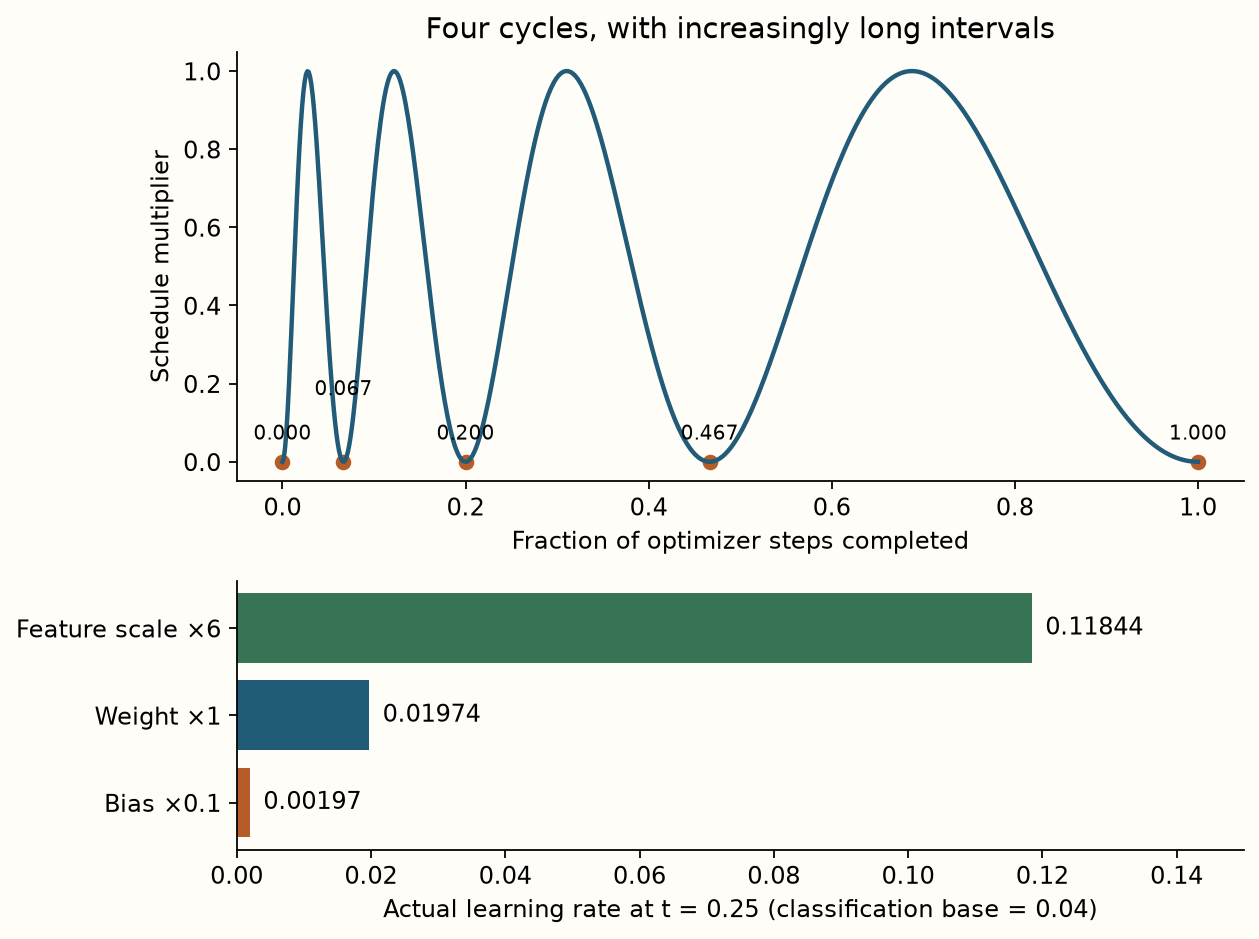

Four-cycle schedule; valleys at 0, 1/15, 3/15, 7/15 and 1. Parameter-group rates differ even at the same training step. [Open full-size figure](figures/l053/schedule.png). On a small screen, open the full-size figure to inspect labels and seed points.

### TODO 4 · Reconstruct the schedule
**Goal:** return the schedule multiplier for normalized optimizer-step progress t. **Why:** an ordinary cosine or equally spaced restart schedule is a different experiment. Use the paper expression above, not a lookup table; the CHECK also probes mid-cycle peaks.

In [ ]:
# TODO — coslog4
def coslog4(t):
    raise NotImplementedError("Implement this live function")

In [ ]:
# CHECK — analytical valleys and peaks; non-grid argument
for j in range(5):assert abs(coslog4((2**j-1)/15))<1e-12
for j in range(4):assert abs(coslog4((2**(j+.5)-1)/15)-1)<1e-12
assert 0<=coslog4(.371)<=1
print('PASS: four logarithmically spaced cycles')

In [ ]:
# PROVIDED — validation tie policy
def last_best(history):
    """Minimize validation error; choose the latest epoch in an exact tie."""
    if not len(history) or not np.isfinite(history).all():
        raise ValueError('Expected nonempty finite validation errors')
    return len(history) - 1 - int(np.argmin(history[::-1]))
assert last_best([.4,.3,.35,.3])==3

**Connecting the ideas.** A transferable default is a claim about the whole recipe across tasks. Compare that procedure with fixed and tuned alternatives under declared budgets; otherwise an architecture label can hide unequal selection effort.

## 6. What exactly are we comparing?




The curriculum asks for RealMLP versus tuned XGBoost. “Tuned” needs a search space, budget and selection rule. We run six XGBoost candidates: depth in {3,6} crossed with learning rate in {0.03,0.1,0.2}. Each has at most 150 trees, validation early stopping with patience 20, row and column sampling of 0.8, and one CPU thread. Validation error selects the candidate; the first candidate, depth 3/rate 0.03, is also reported as **XGB-fixed**. It is our declared baseline, not XGBoost’s library default.




This is a comparison of deployment procedures: one fixed neural recipe versus a six-candidate tree search. It is neither equal wall-clock compute nor an exhaustive tree search. The fixed and tuned tree reports share the first fitted candidate; they are statistically dependent. XGBoost gets the imputed numeric values directly, while the neural arm also applies its prescribed transform. Holding out the same rows and using the same metric is appropriate; forcing identical preprocessing would change the methods being tested.




**Data contract:** three real numeric tasks—California Housing, House 16H and Higgs Small—from the author-released TabR archive already used in L052. We preserve those released train/validation/test boundaries and take label-blind row caps of 1200/600/600 with seeds 53/54/55. Model seeds are 0/1/2. Reusing this compact verified archive avoids requiring the full RealMLP benchmark archive for a CPU lesson. It does not recreate RealMLP’s datasets/splits protocol.




The full meta-train and meta-test classification/regression suites, the full Grinsztajn suite, and the categorical paths are unrun. Familiar source dataset names do not establish identical preprocessing, versions or splits. These three already familiar course datasets are not an untouched meta-test set for us. We freeze the lesson recipe before inspecting scores and make no new claim that our own defaults generalize to unseen tasks.




Prediction files, split row indices, source/data hashes, library versions, all validation candidates and selected epochs are recorded. Read the [reproducibility contract](l053-reproduction.md), [local evidence](_verify_l053_results.json) and [source parity checks](_source_check_l053_results.json). The local target is a correct experiment with an honest **INCOMPARABLE** paper verdict.

In [ ]:
# PROVIDED — data and metric helpers (statistics fit on training only)
def load_task(name, train_cap=1200, eval_cap=600, data_root='data/cache/l052'):
    arrays, labels, selection, hashes = {}, {}, {}, {}
    for j, split in enumerate(('train','val','test')):
        root=Path(data_root)/name
        for prefix in ('X_num','Y'):
            p=root/f'{prefix}_{split}.npy';hashes[p.name]=hashlib.sha256(p.read_bytes()).hexdigest()
        x=np.load(root/f'X_num_{split}.npy');y=np.load(root/f'Y_{split}.npy')
        cap=train_cap if split=='train' else eval_cap
        idx=np.random.default_rng(53+j).permutation(len(x))[:min(cap or len(x),len(x))]
        arrays[split],labels[split],selection[split]=x[idx],y[idx],idx.tolist()
    median=np.nanmedian(arrays['train'],axis=0)
    arrays={s:np.where(np.isnan(x),median,x).astype('float32') for s,x in arrays.items()}
    if not all(np.isfinite(x).all() for x in arrays.values()):raise ValueError('Nonfinite input')
    regression=name!='higgs-small'
    mean=float(labels['train'].mean()) if regression else 0.
    std=float(labels['train'].std()) if regression else 1.
    if std<=0:raise ValueError('Constant target')
    return dict(raw=arrays,y={s:((v-mean)/std).astype('float32') for s,v in labels.items()},
                regression=regression,target_std=std,target_mean=mean,selection=selection,hashes=hashes)

def error(prediction, target, regression, target_std=1.):
    if regression:return float(np.sqrt(np.mean((np.asarray(prediction).reshape(-1)-target)**2))*target_std)
    return float(np.mean(np.asarray(prediction).argmax(-1)!=target))

In [ ]:
# PROVIDED — visible neural training loop, calls your model and schedule
def fit_neural(model_class, data, seed, width=64, epochs=64, device='cpu', prep_class=RobustSmooth):
    start=time.perf_counter();torch.manual_seed(seed)
    prep=prep_class().fit(data['raw']['train'])
    xs={s:torch.as_tensor(prep.transform(x),device=device) for s,x in data['raw'].items()}
    regression=data['regression']
    ys={s:torch.as_tensor(y,dtype=torch.float32 if regression else torch.long,device=device)
        for s,y in data['y'].items()}
    model=model_class(xs['train'].shape[1],width=width,regression=regression).to(device)
    # Weight decay is zero in TD-S; Adam and AdamW then implement the same updates.
    optimizer=torch.optim.Adam(model.parameter_groups(),betas=(.9,.95),eps=1e-8,weight_decay=0.)
    loader=DataLoader(TensorDataset(xs['train'],ys['train']),batch_size=min(256,len(xs['train'])),
                      shuffle=True,drop_last=True)
    base_lr=.07 if regression else .04
    history=[];best=float('inf');best_state=None
    for epoch in range(epochs):
        model.train()
        for batch,(x,y) in enumerate(loader):
            t=(epoch*len(loader)+batch)/(epochs*len(loader))
            for group in optimizer.param_groups:group['lr']=base_lr*group['factor']*coslog4(t)
            prediction=model(x)
            loss=nn.functional.mse_loss(prediction[:,0],y) if regression else nn.functional.cross_entropy(prediction,y,label_smoothing=.1)
            if not torch.isfinite(loss):raise RuntimeError('Nonfinite training loss')
            optimizer.zero_grad();loss.backward();optimizer.step()
        model.eval()
        with torch.no_grad():
            p=torch.cat([model(batch) for batch in xs['val'].split(1024)]).cpu().numpy()
        e=error(p,data['y']['val'],regression,data['target_std']);history.append(e)
        if e<=best:best=e;best_state=copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    with torch.no_grad():p=torch.cat([model(batch) for batch in xs['test'].split(1024)]).cpu().numpy()
    return dict(seed=seed,error=error(p,data['y']['test'],regression,data['target_std']),
                prediction=p.tolist(),history=history,best_epoch=last_best(history)+1,
                seconds=time.perf_counter()-start)

### Read the selection boundary before training
`fit_neural` reads validation errors for checkpoint selection and accesses test predictions after restoring that checkpoint. `fit_trees` selects one of six candidates using validation, then scores only the fixed and selected candidates on test. Predict which method will lead on each task, and whether tree tuning will improve every test score. No CHECK requires a particular winner.

In [ ]:
# PROVIDED — declared search and visible tree selection
SEARCH = [dict(max_depth=d, learning_rate=lr) for d in (3,6) for lr in (.03,.1,.2)]

def fit_trees(data, seed, trees=150, candidates=6):
    """One fixed first candidate, then validation-only search; test evaluated after selection."""
    start=time.perf_counter();reg=data['regression'];models=[];records=[]
    cls=XGBRegressor if reg else XGBClassifier
    for config in SEARCH[:candidates]:
        model=cls(**config,n_estimators=trees,early_stopping_rounds=20,
                  eval_metric='rmse' if reg else 'error',tree_method='hist',n_jobs=1,
                  subsample=.8,colsample_bytree=.8,random_state=seed)
        model.fit(data['raw']['train'],data['y']['train'],
                  eval_set=[(data['raw']['val'],data['y']['val'])],verbose=False)
        p=model.predict(data['raw']['val']) if reg else model.predict_proba(data['raw']['val'])
        e=error(p,data['y']['val'],reg,data['target_std'])
        models.append(model);records.append(dict(config=config,validation_error=e,best_iteration=int(model.best_iteration)))
    chosen=int(np.argmin([r['validation_error'] for r in records]))
    result={}
    for arm,index in [('XGB-fixed',0),('XGB-tuned',chosen)]:
        model=models[index]
        p=model.predict(data['raw']['test']) if reg else model.predict_proba(data['raw']['test'])
        result[arm]=dict(seed=seed,error=error(p,data['y']['test'],reg,data['target_std']),prediction=p.tolist(),
                        selected=index,search=records,seconds=time.perf_counter()-start)
    return result

def run_suite(model_class, names=('california','house','higgs-small'), seeds=(0,1,2),
              train_cap=1200,eval_cap=600,width=64,epochs=64,trees=150,candidates=6,
              device='cpu',data_root='data/cache/l052',prep_class=RobustSmooth,neural_only=False):
    start=time.perf_counter();torch.set_num_threads(1)
    arms=['RealMLP-S'] if neural_only else ['RealMLP-S','XGB-fixed','XGB-tuned']
    result=dict(config=dict(train_cap=train_cap,eval_cap=eval_cap,width=width,epochs=epochs,trees=trees,
                           candidates=candidates,seeds=list(seeds),selection_seeds=[53,54,55],device=device),
                versions={p:importlib.metadata.version(p) for p in ['torch','numpy','scipy','scikit-learn','xgboost']},
                results={},verdict='INCOMPARABLE')
    with threadpool_limits(limits=1):
        for name in names:
            data=load_task(name,train_cap,eval_cap,data_root);runs={a:[] for a in arms}
            for seed in seeds:
                runs['RealMLP-S'].append(fit_neural(model_class,data,seed,width,epochs,device,prep_class))
                if not neural_only:
                    tree_runs=fit_trees(data,seed,trees,candidates)
                    for a in tree_runs:runs[a].append(tree_runs[a])
                print(name,seed,{a:round(runs[a][-1]['error'],5) for a in arms},flush=True)
            result['results'][name]=dict(metric='RMSE' if data['regression'] else 'classification error',
                runs=runs,summary={a:seed_interval([r['error'] for r in runs[a]]) for a in arms},
                selection=data['selection'],hashes=data['hashes'],target_std=data['target_std'])
    if len(names)>=3 and len(arms)>=3:
        means=np.array([[result['results'][name]['summary'][a]['mean'] for a in arms] for name in names])
        ranks=np.array([rankdata(row) for row in means]);test=friedmanchisquare(*means.T)
        cd=float(studentized_range.ppf(.95,len(arms),np.inf)/np.sqrt(2)*np.sqrt(len(arms)*(len(arms)+1)/(6*len(names))))
        result['ranks']=dict(arms=arms,per_dataset=ranks.tolist(),means=dict(zip(arms,ranks.mean(0).tolist())),
                             friedman_stat=float(test.statistic),friedman_p=float(test.pvalue),nemenyi_cd=cd)
    result['elapsed_seconds']=time.perf_counter()-start
    return result

In [ ]:
# PROVIDED — live local experiment (about 30 CPU seconds on the author machine)
live_results=run_suite(RealMLPS,prep_class=RobustSmooth)
rows=[]
for name,data in live_results['results'].items():
    for arm,s in data['summary'].items():
        rows.append(dict(dataset=name,method=arm,metric=data['metric'],mean=s['mean'],sd=s['sd'],ci95=s['ci95']))
display(pd.DataFrame(rows))
display(pd.DataFrame([live_results['ranks']['means']]).T.rename(columns={0:'mean rank'}))
print('Friedman p',live_results['ranks']['friedman_p'],'CD',live_results['ranks']['nemenyi_cd'])

In [ ]:
# CHECK — reconstruct saved errors and selection without trusting summary fields
for name,result in live_results['results'].items():
    data=load_task(name)
    for arm,runs in result['runs'].items():
        for run in runs:
            measured=error(np.array(run['prediction']),data['y']['test'],data['regression'],data['target_std'])
            assert abs(measured-run['error'])<max(1e-6,abs(measured)*1e-6)
            if arm=='RealMLP-S':assert run['best_epoch']==last_best(run['history'])+1
            elif arm=='XGB-tuned':assert run['selected']==int(np.argmin([c['validation_error'] for c in run['search']]))
print('PASS: all 27 errors and validation selections reconstructed')

In [ ]:
# PROVIDED — plot your current kernel results; not the author snapshot
fig,axes=plt.subplots(1,3,figsize=(11,4))
for ax,(name,data) in zip(axes,live_results['results'].items()):
    for i,(arm,runs) in enumerate(data['runs'].items()):
        values=[r['error'] for r in runs];s=seed_interval(values)
        ax.scatter([i-.08,i,i+.08],values,label=arm)
        ax.errorbar(i,s['mean'],yerr=[[s['mean']-s['ci95'][0]],[s['ci95'][1]-s['mean']]],color='black',capsize=3)
    ax.set_title(name);ax.set_ylabel(data['metric']+' ↓');ax.set_xticks([0,1,2],['TD-S','XGB-fixed','XGB-tuned'],rotation=20)
fig.suptitle('Your live runs: seeds and conditional 95% intervals');fig.tight_layout();plt.show()

## 7. Read the evidence without importing a story









| Task / error ↓ | TD-S local | XGB-fixed | XGB-tuned |
| --- | --- | --- | --- |
| California / RMSE | 0.57784 ± 0.01232 | 0.56698 ± 0.00366 | 0.52039 ± 0.00334 |
| House 16H / RMSE | 32597 ± 2844 | 30912 ± 225 | 31521 ± 1072 |
| Higgs / class. error | 0.34722 ± 0.01711 | 0.33278 ± 0.01251 | 0.32278 ± 0.00770 |







Values are mean ± sample standard deviation across three model seeds. RMSE is the square root of mean squared prediction error in original target units. Classification error is the fraction of wrong argmax predictions, not AUROC.




On California, the tree search reduces mean test RMSE by about 0.0466 relative to the fixed candidate, about 8.2%. On House, it raises test RMSE by about 608, about 2.0%. On Higgs, it lowers classification error by 0.0100, one percentage point. Selection improves validation by construction because the fixed candidate is in the search. It does not guarantee a test improvement.





Mean ranks are 3.000, 1.667 and 1.333. The Friedman statistic is 4.667 with approximate p=0.09697; the Nemenyi critical difference is 1.91362. The approximate test does not reject at 5%; it does not demonstrate equality. Three seeds do not increase the number of independent tasks from three to nine. Neither raw RMSE averaging across incompatible units nor treating seeds as datasets would repair that limitation.




The justified conclusion is narrow: the tree recipes have lower mean errors in this capped numeric experiment, and extra validation search can fail to improve a particular test set. It does not show that full RealMLP loses generally, that good defaults are useless, or that the paper was reproduced. We changed width, epoch count, benchmark splits and search scope.

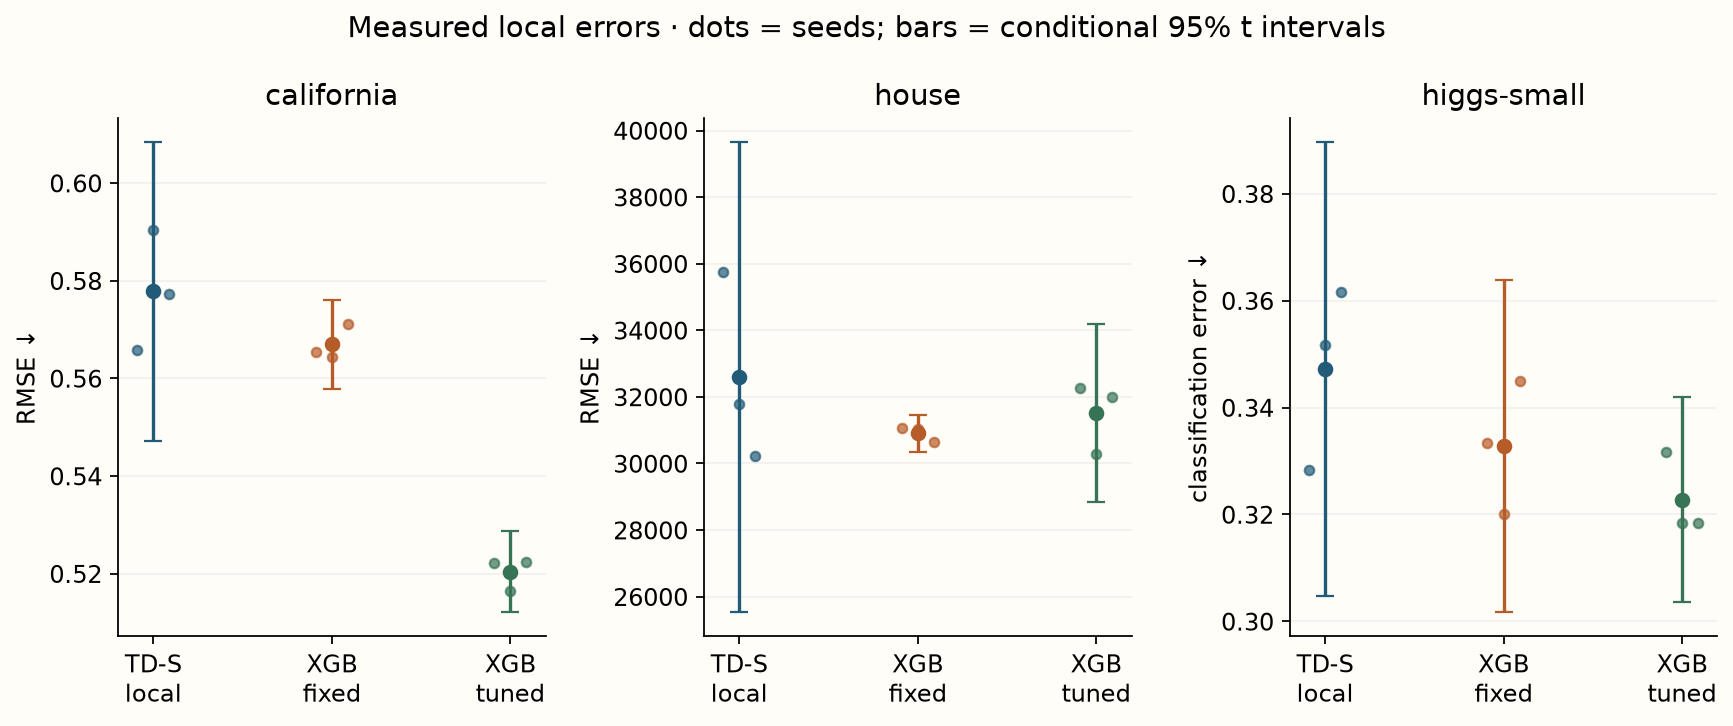

Author-reference local measurement, separate from your current kernel output: errors with seed dots and conditional 95% t intervals. [Open full-size figure](figures/l053/results.png). On a small screen, open the full-size figure to inspect labels and seed points.

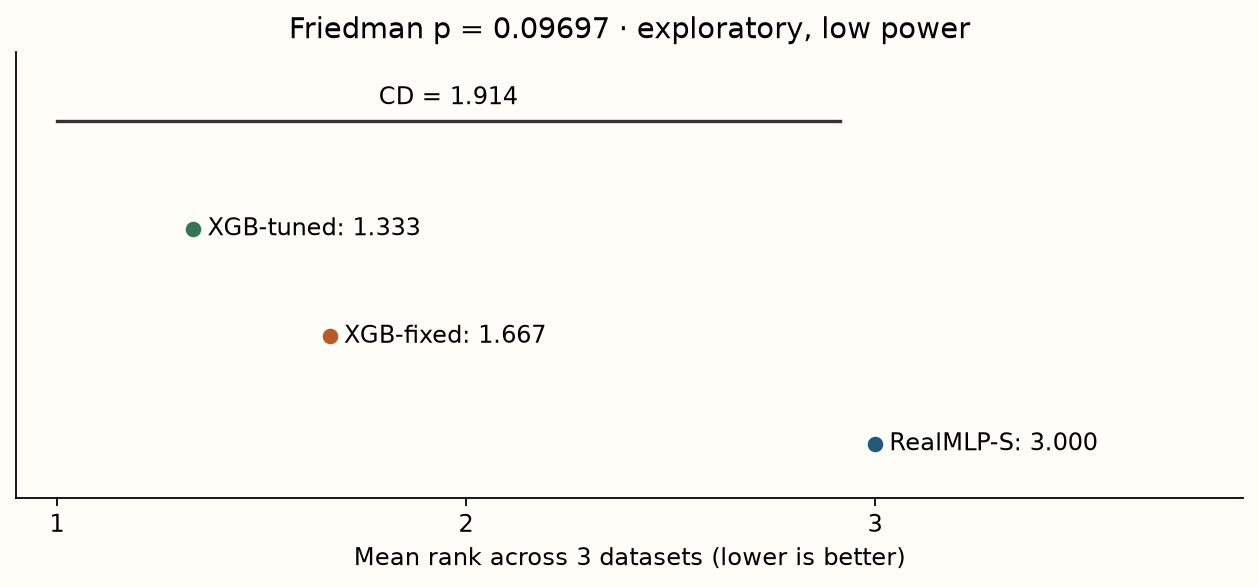

Author-reference ranks across three tasks. A nonsignificant low-power test is not evidence of equivalence. [Open full-size figure](figures/l053/ranks.png). On a small screen, open the full-size figure to inspect labels and seed points.

## 7b. Test the recipe's distinctive preprocessing




The local tree comparison cannot identify which neural component mattered. A controlled intervention can ask a narrower question: what changes if we retain training medians, IQR/range fallbacks, splits, seeds, width, optimizer, schedule and checkpoint policy, but remove only smooth clipping? Both arms train anew. This measures the effect of that change within this fixed recipe; it does not ask for the best learning rate after removing clipping.




**Predict before opening the evidence:** does the saturation formula imply that removing it must hurt every seed? Decide what result would support a consistent benefit and what result would leave the question uncertain.





The closest paper experiment is [Appendix B.2, Table B.2](https://arxiv.org/html/2407.04491v3#A2.SS2), which also uses TD-S and compares preprocessing choices. Removing smooth clipping increased its shifted-geometric benchmark score by 0.5% [−0.4, 1.4] for meta-train classification and 9.5% [4.4, 14.8] for meta-train regression. Those are *relative benchmark-score changes*, not percentage-point classification errors or per-dataset RMSE changes. Their intervals vary ten data splits on fixed benchmark datasets; ours vary three model seeds on fixed capped splits. Both are development experiments. Our result is **INCOMPARABLE** as a reproduction of that table.




Do not generalize this intervention into a proof that every component is independently beneficial. The paper's Figure 1(c) adds components cumulatively and retunes the default learning rate after each stage; Appendix B.1 removes components and again retunes the rate. The authors explain that component order and interactions, including weight decay with Adam β₂, affect the apparent contribution. Our fixed-rate question and their adapted-rate question can legitimately produce different results. A useful next experiment predeclares whether it holds the rate fixed or retunes it, then repeats across new splits before spending more time on architectural speculation.

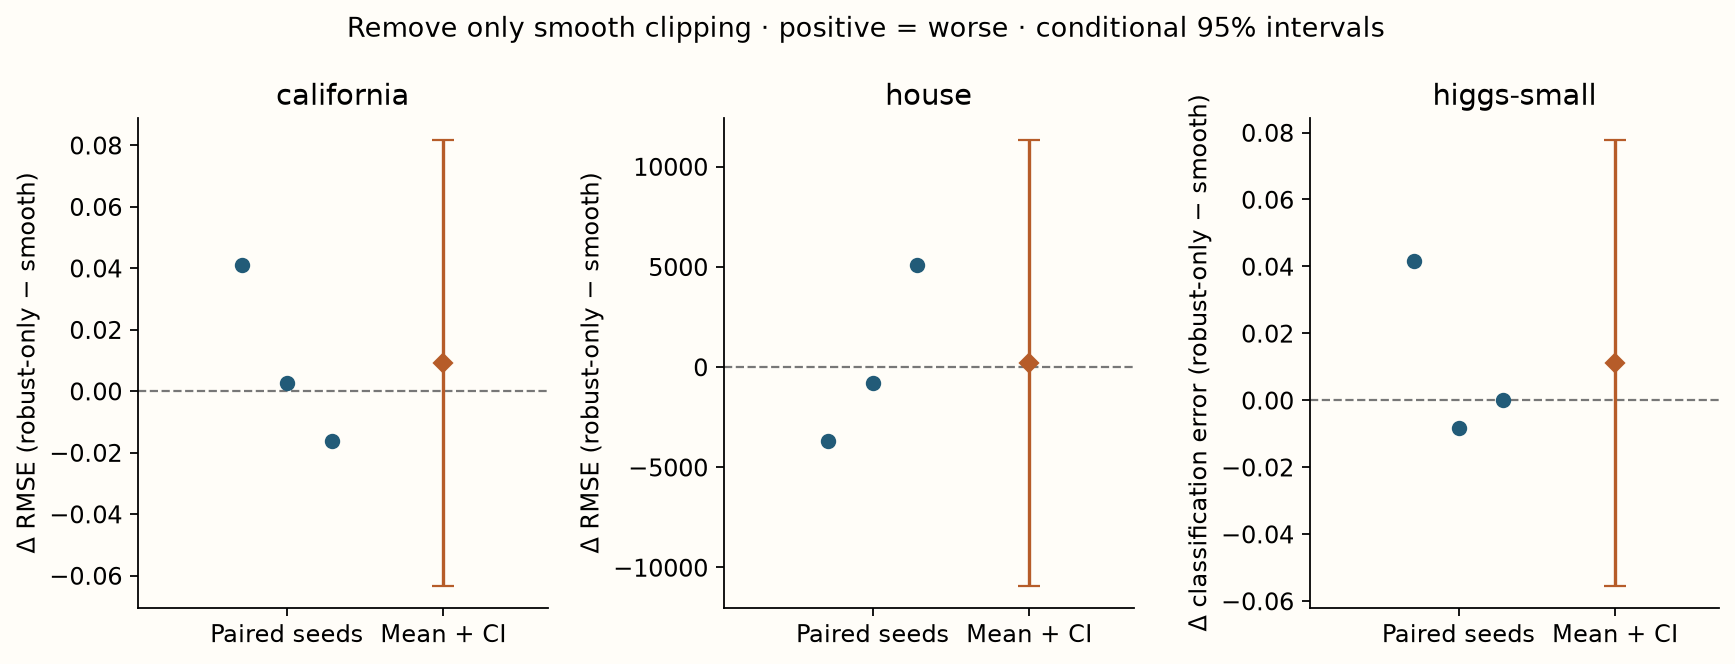

Author-reference paired intervention: remove only smooth clipping. Positive differences mean worse error; every conditional interval includes zero. [Open full-size figure](figures/l053/ablation.png). On a small screen, open the full-size figure to inspect labels and seed points.

### Live intervention · remove just smooth clipping
**Goal:** test the same distinctive preprocessing choice using your live TODO functions. **Why:** a neural-versus-tree score cannot isolate clipping's contribution. **Held fixed:** fitted robust statistics, selected rows, model seeds, widths, losses, rates, schedule and validation rule. **Varied:** the transform after robust scaling. **Measured:** paired test-error changes, one per seed. **Hint:** pair by seed identity, not by list position or separate confidence-interval endpoints. Predict the signs before running. This is a local diagnostic and has no required winner.

The subclass below inherits your live `RobustSmooth.fit`, so the ablated arm still uses your robust-statistics TODO. Both arms use your NTP and schedule TODOs. Only the baseline uses your smooth-clip TODO. We intentionally reuse your already completed baseline fits; retraining them again would add cost without changing this comparison.

In [ ]:
# PROVIDED — one-component intervention and seed-paired uncertainty
class RobustOnly(RobustSmooth):
    """Same fitted medians/scales, including fallbacks; omit only smooth_clip."""
    def transform(self, x):
        return ((np.asarray(x) - self.median) * self.scale).astype('float32')

def paired_effect(baseline, intervention):
    """Positive difference means that removing clipping raised the test error."""
    by_seed = {r['seed']: r['error'] for r in baseline}
    assert len(by_seed) == len(baseline), 'Duplicate baseline seed'
    assert len({r['seed'] for r in intervention}) == len(intervention), 'Duplicate intervention seed'
    assert set(by_seed) == {r['seed'] for r in intervention}, 'Pair identical model seeds'
    differences = [r['error'] - by_seed[r['seed']] for r in intervention]
    return dict(differences=differences, **seed_interval(differences))

In [ ]:
# PROVIDED — live intervention, same local recipe; nine extra neural fits
ablation_results=run_suite(RealMLPS,prep_class=RobustOnly,neural_only=True)
paired_results={}
for name,baseline in live_results['results'].items():
    changed=ablation_results['results'][name]
    assert baseline['selection']==changed['selection'] and baseline['hashes']==changed['hashes']
    paired_results[name]=dict(metric=baseline['metric'],**paired_effect(
        baseline['runs']['RealMLP-S'],changed['runs']['RealMLP-S']))
display(pd.DataFrame(paired_results).T[['metric','differences','mean','sd','ci95']])
# CHECK — pairing survives an order change; stored predictions give the same errors
for name,changed in ablation_results['results'].items():
    data=load_task(name);baseline=live_results['results'][name]['runs']['RealMLP-S']
    reverse=paired_effect(baseline,list(reversed(changed['runs']['RealMLP-S'])))
    np.testing.assert_allclose(reverse['mean'],paired_results[name]['mean'])
    for run in changed['runs']['RealMLP-S']:
        np.testing.assert_allclose(error(np.array(run['prediction']),data['y']['test'],
            data['regression'],data['target_std']),run['error'],rtol=1e-6)
print('PASS: same rows, seed pairing and nine reconstructed intervention scores')

### EXIT TICKET · complete in your own words
Report one selected neural epoch and one selected tree configuration. Explain why the test set did not choose either. Compare fixed and tuned XGB on one task, including units and seed uncertainty. State the number of independent datasets and interpret Friedman without equating non-rejection with equality. Give the paper verdict and two protocol deviations. Explain how a default can embody extensive tuning. Interpret one paired clipping result and propose a next experiment that addresses its uncertainty. Explain why Table B.2's relative SGM changes are not percentage-point changes in our Higgs error.

Paste your output and explanation to the teacher for feedback; passing numerical CHECKs alone does not grade the explanation.

In [ ]:
# EXIT — replace the blank explanation before submitting
interpretation = ''  # TODO: write your own conclusion and protocol limits
print('Paper verdict:',live_results['verdict'])
print('Dataset count:',len(live_results['results']))
print('Mean ranks:',live_results['ranks']['means'])
assert interpretation.strip(), 'Complete the written EXIT explanation before saving your submission'
from _paper_repro_l053 import identity
exit_path=Path('data/cache/l053-student/exit.json');exit_path.parent.mkdir(parents=True,exist_ok=True)
exit_artifact=dict(lesson=53,paper_verdict='INCOMPARABLE',interpretation=interpretation,
    comparison=live_results,intervention=ablation_results,paired=paired_results,
    live_code_identity=identity(RealMLPS,run_suite,RobustSmooth,RobustOnly,paired_effect))
exit_path.write_text(json.dumps(exit_artifact,indent=2))
print('Saved reproducible EXIT:',exit_path.resolve())
print('Your explanation:',interpretation)

## 9. Required next step: use the published recipe size




The larger operator uses the same visible numeric model with three 256-wide hidden layers and 256 epochs. Its `closer` preset takes 6000 California training rows, the full released validation and test sets, and three model seeds. The gated Colab cell runs the live notebook implementation; the [Modal operator](../modal/l053_paper_repro.py) supports unattended execution and completed-seed resume. No cloud job is needed to read this lesson.





Presets are `smoke` (tiny wiring check), `closer` (published width and epochs, capped training rows), and `paper` (published width and epochs, full released California split, ten model seeds). The last name refers to model settings: it still does *not* reproduce ten new paper splits or the full benchmark. That work remains NOT_RUN. A single-task result has no valid scalar target for a benchmark-wide superiority claim.


`modal run --detach modal/l053_paper_repro.py --preset closer
# Or locally, from the repository root:
python labs/_paper_repro_l053.py --preset closer`


The conclusion ledger keeps three buckets: **verified here** (implementation checks and local comparison), **paper claim** (cross-dataset results from the cited source), and **scale-up** (this larger measured regime). The official-source check establishes forward, input-gradient and parameter-gradient agreement with copied weights, plus preprocessing, schedule, four matched-batch Adam updates and moment-state agreement. It does not establish identical end-to-end training trajectories or full pytabkit runtime parity.




Ask me follow-up questions about any derivation, failing CHECK, or conclusion you cannot defend. After this lesson, L054 studies TabM: how to obtain multiple predictors efficiently. Carry this question forward: does the gain come from a better individual model, a better recipe, or an ensemble?

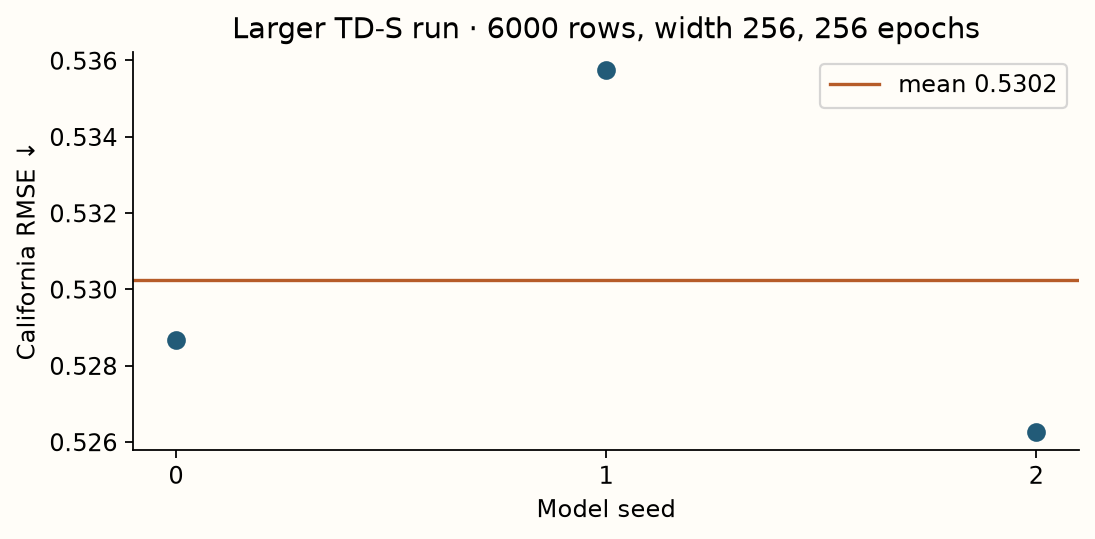

Author-reference larger CPU run: full published width and epochs, 6000 training rows, three seeds. Still a different dataset protocol from the paper. [Open full-size figure](figures/l053/closer.png). On a small screen, open the full-size figure to inspect labels and seed points.

In [ ]:
# PROVIDED — required NEXT STEP, live code; gated OFF by default
RUN_PAPER_REPRO = False
PAPER_PRESET = 'closer'  # smoke / closer / paper (model settings, not benchmark parity)
if RUN_PAPER_REPRO:
    from _paper_repro_l053 import reproduce
    scaleup=reproduce(PAPER_PRESET,out=f'data/cache/l053-notebook-{PAPER_PRESET}',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        model_class=RealMLPS,runner=run_suite,prep_class=RobustSmooth)
    display(pd.DataFrame([scaleup['summary']]))
    print(scaleup['ledger'])
else:
    print('Scale-up for YOUR live code: NOT_RUN. Author larger-run evidence is separate.')

### Return tomorrow
Without reopening the formula, explain the two evaluation levels and reconstruct the zero-IQR fallback. Then name the difference between the TD and TD-S variants. Ask the teacher about any CHECK or derivation you cannot explain.

## Carry this forward

<a href="../lessons/0054-tabm-parameter-efficient-ensembling.html">TabM</a> keeps the strong-baseline perspective but spends shared computation on multiple predictors. The next question is whether their errors are different enough for averaging to help.